# Boolean Networks - Computer Practical

Focus: Network dynamics, state spaces, and predictive modeling

## Instructions for Students
- 🟢 **Code**: Code provided - run and observe
- 🟡 **TODO**: You need to complete these - look for TODO comments
- ❓ **Question**: Analysis questions you need to answer


In [18]:
# 🟢 Setup and Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import seaborn as sns
from itertools import product
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

### What are boolean networks?
Boolean networks are mathematical models where:
*   Each node has a binary state: ON (1) or OFF (0)
*   Nodes update based on Boolean rules (AND, OR, NOT)

### Why should you use Boolean Networks?
*   Handle discrete/categorical data naturally  
*   Model complex systems with simple rules
*   Find stable patterns (attractors) in data
*   Test 'what-if' scenarios (perturbation analysis)







---

### Helper functions to create a Boolean network
Run the following code snippet so the basic functions are available.

In [19]:
# 🟢 Helper class to build and simulate boolean network

class BooleanNetwork:
    def __init__(self, node_names):
        self.nodes = {name: 0 for name in node_names}
        self.rules = {}
        self.history = []
        self.graph = nx.DiGraph()  # NetworkX graph for visualization

        # Add nodes to NetworkX graph
        self.graph.add_nodes_from(node_names)

    def add_rule(self, target_node, rule_function, rule_description=""):
        """
        Add Boolean rule for a node

        Args:
            target_node: Node to update
            rule_function: Function that takes current state dict and returns True/False
            rule_description: Human-readable description
        """
        self.rules[target_node] = {
            'function': rule_function,
            'description': rule_description
        }

    def set_state(self, **kwargs):
        """Set states of specific nodes"""
        for node, value in kwargs.items():
            if node in self.nodes:
                self.nodes[node] = int(bool(value))

    def get_state_vector(self):
        """Get current state as list in sorted order"""
        return [self.nodes[node] for node in sorted(self.nodes.keys())]

    def update_synchronous(self):
        """Update all nodes simultaneously"""
        new_state = {}
        for node in self.nodes:
            if node in self.rules:
                new_state[node] = int(self.rules[node]['function'](self.nodes))
            else:
                new_state[node] = self.nodes[node]  # No rule = no change

        self.nodes = new_state
        self.history.append(self.get_state_vector())

    def simulate(self, steps=10, record_history=True):
        """Run simulation"""
        if record_history:
            self.history = [self.get_state_vector()]

        for step in range(steps):
            self.update_synchronous()

            # Check for steady state
            if len(self.history) >= 2 and self.history[-1] == self.history[-2]:
                print(f"   Reached steady state after {step+1} steps")
                break

        return np.array(self.history)

### BooleanNetwork helper class

The BooleanNetwork class provides the basic structure used to build and simulate the Boolean networks 

Each node has a binary state:
`0` = OFF
`1` = ON




---



## Part 1: Simple 3-node Boolean network

Let's first play with a simple 3-node example network

In [20]:
# 🟢 Helper class to build and simulate boolean network

print("Demo: Creating a simple 3-node Boolean network")

demo = BooleanNetwork(['A', 'B', 'C'])

# Add rules with clear descriptions
demo.add_rule('A', lambda state: not state['C'], "A = NOT C")
demo.add_rule('B', lambda state: state['A'] and state['C'], "B = A AND C")
demo.add_rule('C', lambda state: state['A'] or state['B'], "C = A OR B")

print("Rules:")
for node, rule_info in demo.rules.items():
    print(f"  {node}: {rule_info['description']}")

Demo: Creating a simple 3-node Boolean network
Rules:
  A: A = NOT C
  B: B = A AND C
  C: C = A OR B


### Simple 3-Node Boolean Network

This example illustrates the construction of a Boolean network using three nodes (A, B, and C). Each node is assigned a logical update rule using add_rule(), defining how its state depends on the other nodes. The example introduces the network structure and rule-based dynamics used later in the cell regulatory model.

❓ **Question**: How does the system look like? Draw the directed network structure on paper based on the logical rules!

The network contains five directed interactions: C inhibits A, while A activates B and C, C activates B, and B activates C.

In [21]:
# 🟢 Test simulation
demo.set_state(A=1, B=0, C=0)
print(f"\nStarting state: A=1, B=0, C=0")

trajectory = demo.simulate(steps=6)
print("Trajectory:")
for i, state in enumerate(trajectory):
    state_dict = {node: state[j] for j, node in enumerate(sorted(demo.nodes.keys()))}
    print(f"  Step {i}: A={state_dict['A']}, B={state_dict['B']}, C={state_dict['C']}")


Starting state: A=1, B=0, C=0
Trajectory:
  Step 0: A=1, B=0, C=0
  Step 1: A=1, B=0, C=1
  Step 2: A=0, B=1, C=1
  Step 3: A=0, B=0, C=1
  Step 4: A=0, B=0, C=0
  Step 5: A=1, B=0, C=0
  Step 6: A=1, B=0, C=1



The network is initialized with the state A=1, B=0, C=0 and simulated for six synchronous update steps. The resulting trajectory is recorded to observe the behavior of the network.

❓ **Question**: What pattern do you observe?

*   Reaches stable state
*   Oscillates forever <-------     
*   Grows exponentially
*   Random behavior


we can see that the state returns to (A=1, B=0, C=0) at Step 5, after which the same sequence begins again. This is a limit cycle, rather than a stable state.



---



## Part 2: Simplified cell regulatory network

🧬 Biological context

Cells make binary decisions:
* GROW: Divide and multiply (good for healing, bad if uncontrolled)
* DIE: Self-destruct (protective mechanism, prevents cancer)
* REST: Stay inactive (safe default state)

Key molecular switches (think: binary variables):
* DNA_damage: External damage signal (input variable)
* p53: "Tumor suppressor" - master safety switch that detects problems
* MYC: "Oncogene" - growth promoter that drives cell division
* CDK2: Cell division machinery that executes growth
* MDM2: "p53 inhibitor" - blocks p53 function (cancer exploit!)
* p21: "Cell cycle brake" - stops division when problems detected
* Growth/Death: Final binary decisions (outputs)

In [22]:
# 🟢 Create the regulatory network
nodes = ['DNA_damage', 'p53', 'MYC', 'CDK2', 'MDM2', 'p21', 'Growth', 'Death']
network = BooleanNetwork(nodes)

# Define Boolean rules (based on real biology, simplified)
network.add_rule('DNA_damage', lambda s: s['DNA_damage'], "DNA_damage = INPUT (constant)")
network.add_rule('p21', lambda s: s['p53'], "p21 = p53")
network.add_rule('MYC', lambda s: (not s['p53']) and (not s['p21']), "MYC = (NOT p53) AND (NOT p21)")
network.add_rule('CDK2', lambda s: s['MYC'] and (not s['p21']) and (not s['p53']), "CDK2 = MYC AND (NOT p21) AND (NOT p53)")
network.add_rule('MDM2', lambda s: s['MYC'], "MDM2 = MYC")
network.add_rule('p53', lambda s: s['DNA_damage'] and not s['MDM2'], "p53 = DNA_damage AND (NOT MDM2)")
network.add_rule('Growth',lambda s: s['CDK2'] and s['MYC'] and (not s['p53']), "Growth = CDK2 AND MYC AND (NOT p53)")
network.add_rule('Death', lambda s: s['p53'] and s['DNA_damage'] and (not s['Growth']), "Death = p53 AND DNA_damage AND (NOT Growth)")

print("Rules:")
for node, rule_info in network.rules.items():
    print(f" {rule_info['description']}")

Rules:
 DNA_damage = INPUT (constant)
 p21 = p53
 MYC = (NOT p53) AND (NOT p21)
 CDK2 = MYC AND (NOT p21) AND (NOT p53)
 MDM2 = MYC
 p53 = DNA_damage AND (NOT MDM2)
 Growth = CDK2 AND MYC AND (NOT p53)
 Death = p53 AND DNA_damage AND (NOT Growth)


### Construction of the Cell Regulatory Network

The regulatory network consists of eight Boolean nodes representing DNA damage, regulatory molecules, and cell fate outputs. Each node is assigned a logical update rule describing its interactions with the other components.

DNA_damage is treated as a constant external input, while the remaining nodes are updated synchronously according to their Boolean rules. This network represents the normal model and serves as the baseline for the mutation analyses.

❓ **Question**: How does the system look like? Draw the directed network structure on paper based on the logical rules!

- DNA damage: External input signal that remains constant during a simulation.
- p53 Activated by DNA damage and inhibited by MDM2.
- p21: activated by p53.
- MYC: Inhibited by p53 and p21.
- CDK2: Activated by MYC and inhibited by p21 and p53.
- MDM2: Activated by MYC.
- Growth: Activated by CDK2 and MYC when p53 is inactive.
- Death: Activated by p53 and DNA damage when Growth is inactive.

### Predict the outcomes
❓ **Question**: Before running simulations, make your predictions:

Scenarios:
*   Healthy Cell: `{'DNA_damage': 0, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}`
*   Stressed Cell (Repairable): `{'DNA_damage': 1, 'p53': 0, 'MYC': 0, 'CDK2': 0,'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}`
*   Oncogene Hijacked Cell: `{'DNA_damage': 0, 'p53': 0, 'MYC': 1, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}`

For each scenario, decide on the final growth, death and p53 state (0 or 1).

Healthy Cell: Growth = 0, Death = 0, p53 = 0
Stressed Cell: p53 has to be active becauseof DNA damage 
Oncogene Hijacked Cell:


### Predicted Outcomes

- Healthy Cell: Growth = 1, Death = 0, p53 = 0
- Stressed Cell: Growth = 0, Death = 1, p53 = 1
- Oncogene Hijacked Cell: Growth = 1, Death = 0, p53 = 0

The stressed cell is expected to activate p53 in response to DNA damage, suppressing growth and promoting cell death. The hijacked cell is expected to maintain growth due to MYC activity.

### Scenario Simulation

Three initial conditions are defined to represent a healthy cell, a stressed cell with DNA damage, and an oncogene-hijacked cell. Each scenario is simulated for eight synchronous update steps, and the final states of Growth, Death and p53 are recorded for comparison.

In [23]:
# 🟡 Example code for healthy cell below, adapt to also run Stressed Cell and Oncogene Hijacked Cell scenarios

scenarios = {
    'Healthy Cell': {'DNA_damage': 0, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Stressed Cell': { 'DNA_damage': 1, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Oncogene Hijacked Cell': { 'DNA_damage': 0, 'p53': 0, 'MYC': 1, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}
}

results = {}

# Run healthy cell scenario
s = "Healthy Cell"
initial_state = scenarios[s]
network.set_state(**initial_state)
trajectory = network.simulate(steps=8)
results[s] = trajectory

final_state = trajectory[-1]
node_names = sorted(network.nodes.keys())
final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

print(f"   {s}: Final state: Growth={final_dict['Growth']}, Death={final_dict['Death']}, p53={final_dict['p53']}")

# Run stressed cell scenario
s = "Stressed Cell"
initial_state = scenarios[s]
network.set_state(**initial_state)
trajectory = network.simulate(steps=8)
results[s] = trajectory

final_state = trajectory[-1]
node_names = sorted(network.nodes.keys())
final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

print(f"{s}: Final state: Growth={final_dict['Growth']}, Death={final_dict['Death']}, p53={final_dict['p53']}")


# Run oncogene hijacked cell scenario
s = "Oncogene Hijacked Cell"
initial_state = scenarios[s]
network.set_state(**initial_state)
trajectory = network.simulate(steps=8)
results[s] = trajectory

final_state = trajectory[-1]
node_names = sorted(network.nodes.keys())
final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

print(f"{s}: Final state: Growth={final_dict['Growth']}, Death={final_dict['Death']}, p53={final_dict['p53']}")


# TODO: Repeat for other scenarios!

   Reached steady state after 4 steps
   Healthy Cell: Final state: Growth=1, Death=0, p53=0
   Reached steady state after 6 steps
Stressed Cell: Final state: Growth=0, Death=1, p53=1
   Reached steady state after 3 steps
Oncogene Hijacked Cell: Final state: Growth=1, Death=0, p53=0


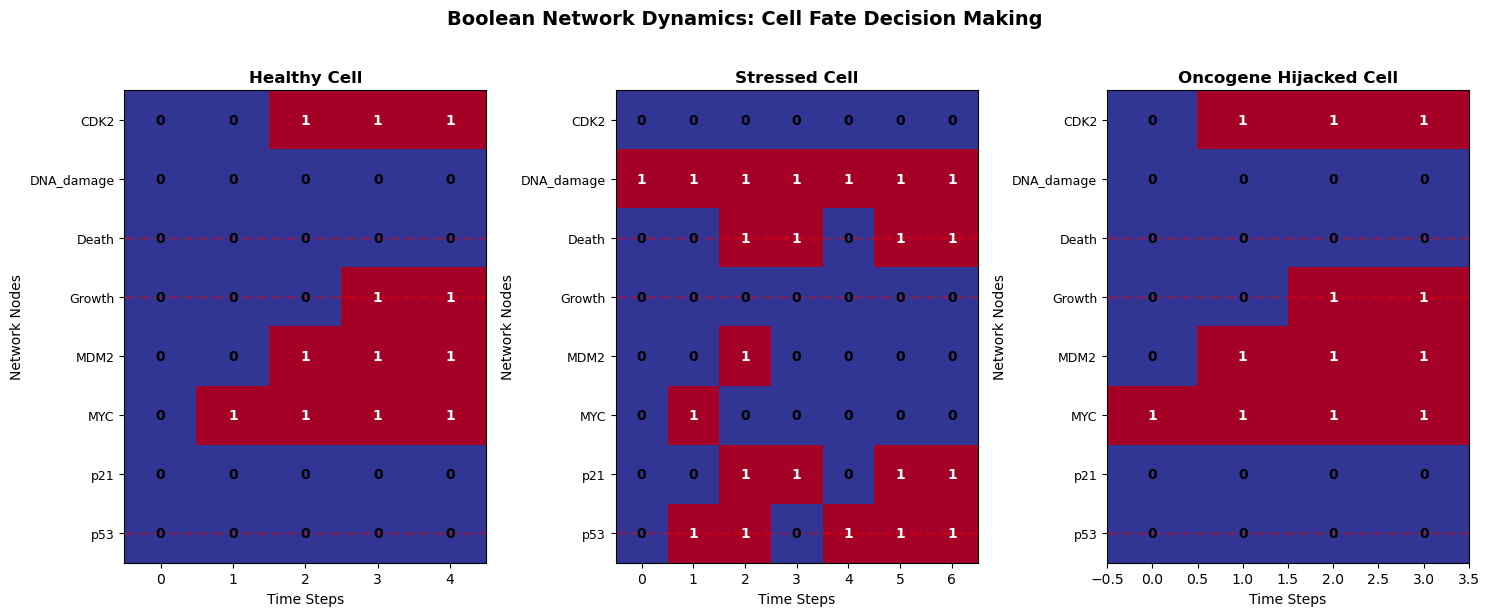

In [24]:
# 🟢 Visualize results
n_scenarios = len(results)
fig, axes = plt.subplots(1, n_scenarios, figsize=(5*n_scenarios, 6))

if n_scenarios == 1:
    axes = [axes]

for scenario_idx, (scenario_name, trajectory) in enumerate(results.items()):
    ax = axes[scenario_idx]

    # Create heatmap
    trajectory_matrix = trajectory.T  # Transpose for proper orientation

    im = ax.imshow(trajectory_matrix, cmap='RdYlBu_r', aspect='auto', interpolation='nearest')

    # Formatting
    ax.set_title(f'{scenario_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Time Steps', fontsize=10)
    ax.set_ylabel('Network Nodes', fontsize=10)
    ax.set_yticks(range(len(node_names)))
    ax.set_yticklabels(node_names, fontsize=9)

    # Add text annotations
    for t in range(trajectory.shape[0]):
        for n in range(len(node_names)):
            color = 'white' if trajectory_matrix[n, t] == 1 else 'black'
            ax.text(t, n, int(trajectory_matrix[n, t]),
                   ha="center", va="center", color=color, fontweight='bold')

    # Highlight key output nodes
    output_indices = [i for i, name in enumerate(node_names) if name in ['Growth', 'Death', 'p53']]
    for output_idx in output_indices:  # Changed variable name to avoid conflict
        ax.axhline(y=output_idx, color='red', linestyle='--', alpha=0.3, linewidth=2)

plt.suptitle('Boolean Network Dynamics: Cell Fate Decision Making',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

❓ **Question**: Were your predictions for each scenario correct?
1. Which scenario leads to cell growth? Healthy Cell and Oncogene Hijacked Cell
2. Which scenario leads to cell death? Stressed Cell 
3. How does p53 affect MYC?  p53 suppresses MYC (MYC = (NOT p53) AND (NOT p21))
4. What happens when there's no DNA damage? p53 stays inactive, death stays inactive so the cells grows


---

## **Part 3: Attractor analysis**

Attractors = stable states the network eventually reaches from any starting oint

Types:
* Fixed Point: Network stops changing (steady state)
* Limit Cycle: Network oscillates in repeating pattern  

Why is this important?
* Represent system's natural 'destinations'
* Can predict long-term behavior
* Identify stable patterns in system
* Design interventions to reach desired attractors

In [25]:
# 🟡 Let's find the attractor states
import itertools

attractors = []
max_steps = 15

node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)


print(f"Testing all {2**n_nodes} possible initial states...")

# TODO: Generate all possible initial states
# Hint: Use itertools.product([0, 1], repeat=n_nodes)
all_states =itertools.product([0, 1], repeat=n_nodes)

for initial_state in all_states:
  # Set the network to this initial state
  state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
  network.set_state(**state_dict)

  # TODO: Simulate the network
  trajectory = network.simulate(steps=max_steps)

  # Check if it reached a steady state (last two states are the same)
  if len(trajectory) >= 2:

        if np.array_equal(trajectory[-1], trajectory[-2]):

            final_state = tuple(int(x) for x in trajectory[-1])

            # Store only unique attractors
            if final_state not in attractors:
                attractors.append(final_state)


print(f"\nFound {len(attractors)} fixed-point attractors.")

Testing all 256 possible initial states...
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reac

### Attractor Identification

All 2^8 = 256 possible initial states are generated using itertools.product()
Each state is simulated for up to 15 synchronous update steps. A fixed point attractor is identified when two consecutive states are identical, indicating that the network has reached a stable state.

❓ **Questions and interpretation**
1. How many total states did we test? 256
2. Why does the number of states grow so quickly? Because every node has 2 possible values 0 or 1 so each new node doubles the number of possible states. The growth is exponential (2exp)
3. What would happen if we had 15 nodes instead of 8? We would have to test 2^15 possible states,


1-256

2-Because every node has 2 possible values 0 or 1 so each new node doubles the number of possible states. The growth is exponential (2exp)

3- We would have to test 2^15 possible states,



FOUND 3 ATTRACTORS:

Attractor 1: [1, 0, 0, 1, 1, 1, 0, 0]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: OFF
   → NORMAL GROWTH - Healthy proliferating state

Attractor 2: [0, 1, 1, 0, 0, 0, 1, 1]
   Growth: OFF
   Death: ON
   p53: ON
   DNA Damage: ON
   → CELL DEATH - Protective response to DNA damage

Attractor 3: [1, 1, 0, 1, 1, 1, 0, 0]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: ON
   → CANCER-LIKE - Growth continues despite DNA damage


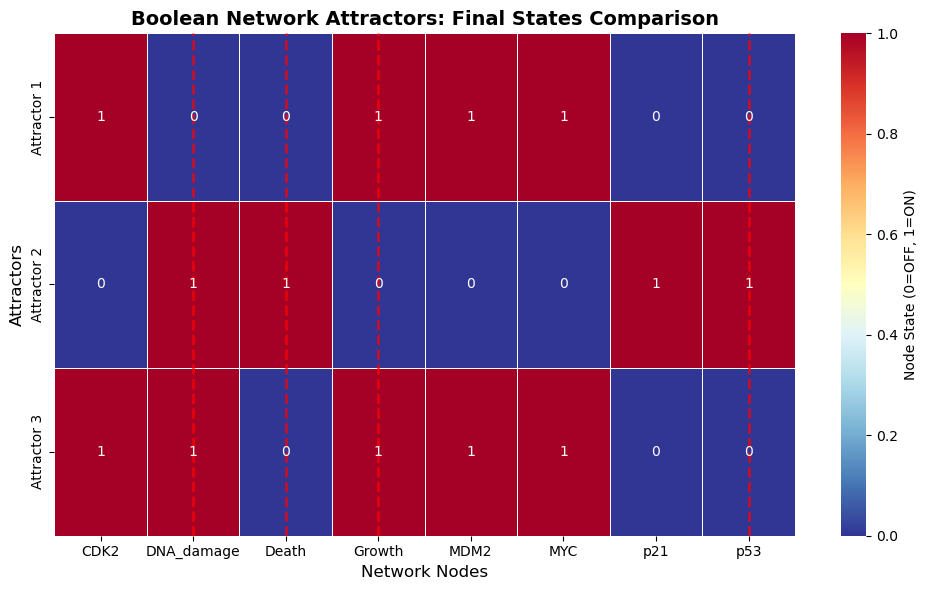

In [26]:
# 🟡 Let's find the attractor states

print(f"\nFOUND {len(attractors)} ATTRACTORS:")

for i, attractor in enumerate(attractors):
        print(f"\nAttractor {i+1}: {list(attractor)}")

        # Create state dictionary for easy access
        state_dict = {node_names[j]: attractor[j] for j in range(len(node_names))}

        # Analyze the biological meaning
        growth_active = state_dict['Growth'] == 1
        death_active = state_dict['Death'] == 1
        p53_active = state_dict['p53'] == 1
        dna_damage_active = state_dict['DNA_damage'] == 1


        print(f"   Growth: {'ON' if growth_active else 'OFF'}")
        print(f"   Death: {'ON' if death_active else 'OFF'}")
        print(f"   p53: {'ON' if p53_active else 'OFF'}")
        print(f"   DNA Damage: {'ON' if dna_damage_active else 'OFF'}")

        # TODO: Interpret the meaning
        if growth_active and not death_active and not dna_damage_active:
            interpretation = "NORMAL GROWTH - Healthy proliferating state"
        elif death_active and not growth_active:
            interpretation = "CELL DEATH - Protective response to DNA damage"
        elif growth_active and not death_active and dna_damage_active:
            interpretation = "CANCER-LIKE - Growth continues despite DNA damage"
        else:
            interpretation = "CONFLICT - Unusual state"

        print(f"   → {interpretation}")


# Convert attractors to clean matrix
attractor_matrix = []
for attractor in attractors:
    clean_row = [int(x) for x in attractor]
    attractor_matrix.append(clean_row)

attractor_matrix = np.array(attractor_matrix)

# Create heatmap
plt.figure(figsize=(10, max(6, len(attractors))))

# Create heatmap with custom colors
ax = sns.heatmap(attractor_matrix,
                 xticklabels=node_names,
                 yticklabels=[f'Attractor {i+1}' for i in range(len(attractors))],
                 cmap='RdYlBu_r',
                 cbar_kws={'label': 'Node State (0=OFF, 1=ON)'},
                 annot=True,
                 fmt='d',
                 linewidths=0.5)

plt.title('Boolean Network Attractors: Final States Comparison',
          fontsize=14, fontweight='bold')
plt.xlabel('Network Nodes', fontsize=12)
plt.ylabel('Attractors', fontsize=12)

# Highlight key output nodes
output_nodes = ['Growth', 'Death', 'p53', 'DNA_damage']
for node in output_nodes:
    if node in node_names:
        idx = node_names.index(node)
        ax.axvline(x=idx+0.5, color='red', linestyle='--', alpha=0.7, linewidth=2)

plt.tight_layout()
plt.show()

### Attractor Interpretation and Visualization

The identified fixed point attractors are classified according to the states of Growth, Death, p53, and DNA damage.

❓ **Questions and interpretation**
1. How many attractors did we find?
2. What does each attractor represent biologically?
3. Which attractor represents a 'healthy' cell state and which one a cancerous' cell state?



1- we found 3 attractors 
\
2- Attractor 1: Growth ON, Death OFF, p53 OFF, DNA damage OFF --> a normal proliferating/growing cell.
Attractor 2: Growth OFF, Death ON, p53 ON, DNA damage ON --> a damaged cell undergoing cell death.
Attractor 3: Growth ON, Death OFF, p53 OFF, DNA damage ON --> a cell continues growing despite DNA damage

3-  Attractor 1 might reprensent a healthy cell because there is no DNA damage and the cell can grow normally.
Attractor 3 represents a cancerous cell because DNA damage is present but the cell continues growing while p53 and Death remain OFF.



Analyzing 256 initial states...
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady 

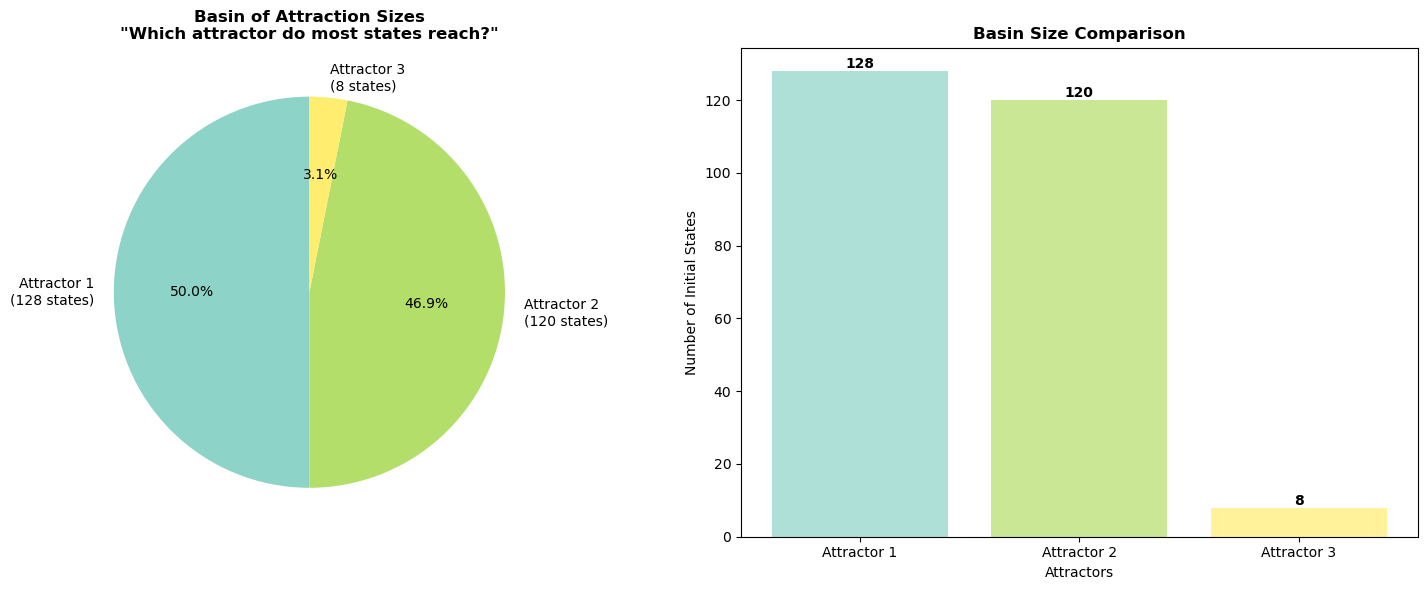

In [27]:
# 🟡 Which states end up in which attractor?

# Track which initial states lead to which attractors
basin_data = defaultdict(list)  # attractor -> list of initial states
attractor_map = {}  # initial_state -> attractor_index

n_nodes = len(node_names)
all_states = list(product([0, 1], repeat=n_nodes))
print(f"Analyzing {len(all_states)} initial states...")

for initial_state in all_states:
    # Set network state
    state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
    network.set_state(**state_dict)

    # Simulate
    trajectory = network.simulate(steps=max_steps, record_history=True)

    # Find which attractor this leads to
    if len(trajectory) >= 2 and np.array_equal(trajectory[-1], trajectory[-2]):
        final_state = tuple(int(x) for x in trajectory[-1])  # Clean conversion

        # Find matching attractor
        for att_idx, attractor in enumerate(attractors):
            clean_attractor = tuple(int(x) for x in attractor)
            if final_state == clean_attractor:
                basin_data[att_idx].append(initial_state)
                attractor_map[initial_state] = att_idx
                break

# Display basin sizes
print(f"\n Basin Sizes:")
total_states = len(all_states)
for att_idx in range(len(attractors)):
    basin_size = len(basin_data[att_idx])
    percentage = (basin_size / total_states) * 100
    print(f"   Attractor {att_idx+1}: {basin_size:3d} states ({percentage:5.1f}%)")

# Create pie chart of basin sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart of basin sizes
basin_sizes = [len(basin_data[i]) for i in range(len(attractors))]
basin_labels = [f'Attractor {i+1}\n({size} states)' for i, size in enumerate(basin_sizes)]
colors = plt.cm.Set3(np.linspace(0, 1, len(attractors)))

wedges, texts, autotexts = ax1.pie(basin_sizes,
                                   labels=basin_labels,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90)

ax1.set_title('Basin of Attraction Sizes\n"Which attractor do most states reach?"',
              fontsize=12, fontweight='bold')

# Bar chart comparison
attractor_names = [f'Attractor {i+1}' for i in range(len(attractors))]
bars = ax2.bar(attractor_names, basin_sizes, color=colors, alpha=0.7)

ax2.set_title('Basin Size Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Initial States', fontsize=10)
ax2.set_xlabel('Attractors', fontsize=10)

# Add value labels on bars
for bar, size in zip(bars, basin_sizes):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{size}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


 Basin Sizes:
   Attractor 1: 128 states ( 50.0%)
   Attractor 2: 120 states ( 46.9%)
   Attractor 3:   8 states (  3.1%)


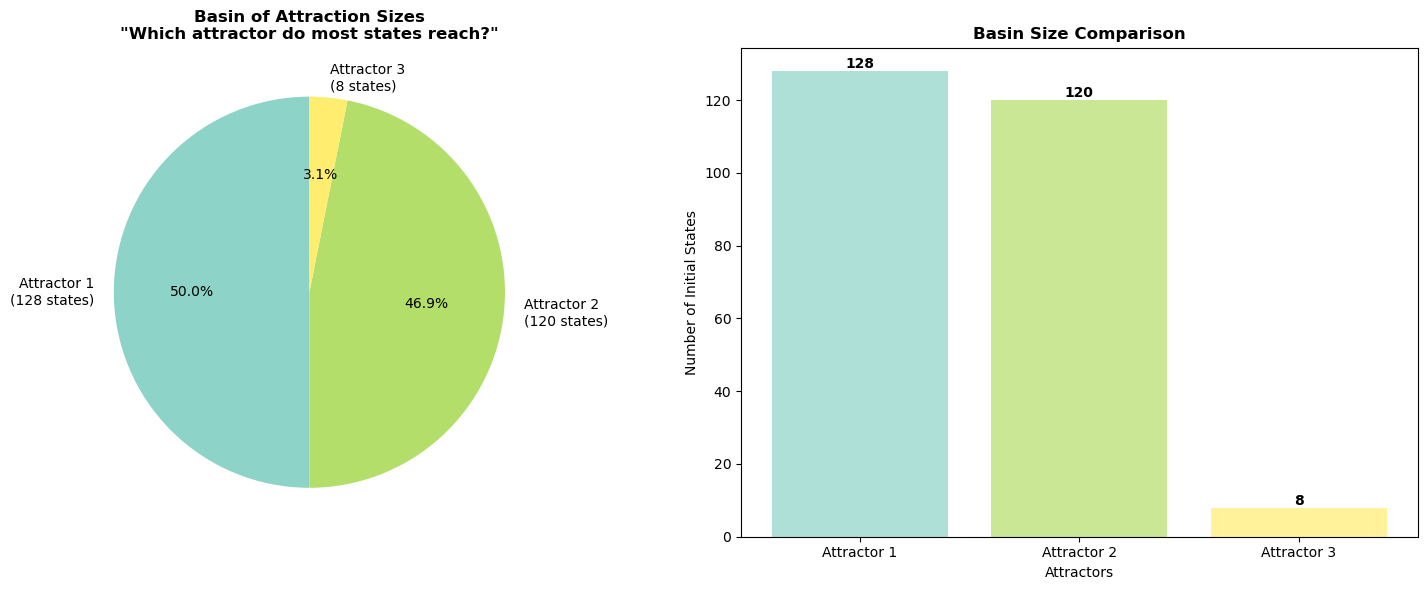

In [28]:
# Display basin sizes
print(f"\n Basin Sizes:")
total_states = len(all_states)
for att_idx in range(len(attractors)):
    basin_size = len(basin_data[att_idx])
    percentage = (basin_size / total_states) * 100
    print(f"   Attractor {att_idx+1}: {basin_size:3d} states ({percentage:5.1f}%)")

# Create pie chart of basin sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart of basin sizes
basin_sizes = [len(basin_data[i]) for i in range(len(attractors))]
basin_labels = [f'Attractor {i+1}\n({size} states)' for i, size in enumerate(basin_sizes)]
colors = plt.cm.Set3(np.linspace(0, 1, len(attractors)))

wedges, texts, autotexts = ax1.pie(basin_sizes,
                                   labels=basin_labels,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90)

ax1.set_title('Basin of Attraction Sizes\n"Which attractor do most states reach?"',
              fontsize=12, fontweight='bold')

# Bar chart comparison
attractor_names = [f'Attractor {i+1}' for i in range(len(attractors))]
bars = ax2.bar(attractor_names, basin_sizes, color=colors, alpha=0.7)

ax2.set_title('Basin Size Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Initial States', fontsize=10)
ax2.set_xlabel('Attractors', fontsize=10)

# Add value labels on bars
for bar, size in zip(bars, basin_sizes):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{size}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

❓ **Questions and interpretation**
* How many initial states lead to each attractor?
* Which attractors are most "popular" (large basins)?

1-Attractor 1: 128 states 
Attractor 2: 120 states 
Attractor 3: 8 states
Total: 256 states

2-Attractor 1 is the most popular, with 128/256 states (50%) (normal growth) 
Attractor 2 is very close, with 120/256 states (46.9%) (damaged cells )
Attractor 3 is much less common, with only 8/256 states (3.1%) (dna damage) 



 # Assignment – Cancer Mutations


In [29]:
# Mutation A: p53 Knockout

network.add_rule('p53',lambda s: False,"p53 = BROKEN (always OFF)")

print("Mutation A: p53 Knockout")

Mutation A: p53 Knockout


### Mutation A p53 Knockout

The normal p53 update rule is replaced by a constant "False" value, representing a loss offunction mutation. As a result, p53 remains inactive regardless of DNA damage or MDM2 activity.

In [30]:
# Test the 3 scenarios with p53 Knockout

results_A = {}

for s in scenarios:
    initial_state = scenarios[s]
    network.set_state(**initial_state)

    trajectory = network.simulate(steps=8)
    results_A[s] = trajectory

    final_state = trajectory[-1]
    node_names = sorted(network.nodes.keys())
    final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

    print(f"{s}: Growth={final_dict['Growth']}, "
          f"Death={final_dict['Death']}, "
          f"p53={final_dict['p53']}")

   Reached steady state after 4 steps
Healthy Cell: Growth=1, Death=0, p53=0
   Reached steady state after 4 steps
Stressed Cell: Growth=1, Death=0, p53=0
   Reached steady state after 3 steps
Oncogene Hijacked Cell: Growth=1, Death=0, p53=0


#### Scenario Analysis

The three predefined scenarios are simulated after the p53 knockout. Their final Growth, Death, and p53 states are compared to evaluate the effect of the mutation on cell fate.

### Attractor Analysis – p53 Knockout

In [31]:
# Attractor analysis for Mutation A

attractors_A = []
basin_A = {}

node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)

all_states = list(itertools.product([0, 1], repeat=n_nodes))

for initial_state in all_states:

    state_dict = {
        node_names[i]: initial_state[i]
        for i in range(n_nodes)
    }

    network.set_state(**state_dict)
    trajectory = network.simulate(steps=15)

    if len(trajectory) >= 2:
        if np.array_equal(trajectory[-1], trajectory[-2]):

            final_state = tuple(int(x) for x in trajectory[-1])

            if final_state not in attractors_A:
                attractors_A.append(final_state)
                basin_A[final_state] = 0

            basin_A[final_state] += 1


   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached s

In [32]:
print("Number of attractors:", len(attractors_A))

for i, attractor in enumerate(attractors_A):

    state = {
        node_names[j]: attractor[j]
        for j in range(n_nodes)
    }

    size = basin_A[attractor]
    percentage = size / 256 * 100

    print(f"\nAttractor {i+1}")
    print("Growth:", state["Growth"])
    print("Death:", state["Death"])
    print("p53:", state["p53"])
    print("DNA damage:", state["DNA_damage"])
    print("Basin:", size, f"({percentage:.1f}%)")
    total_accounted = sum(basin_A.values())
    print(f"\nTotal states accounted for: {total_accounted}/256")

Number of attractors: 2

Attractor 1
Growth: 1
Death: 0
p53: 0
DNA damage: 0
Basin: 128 (50.0%)

Total states accounted for: 256/256

Attractor 2
Growth: 1
Death: 0
p53: 0
DNA damage: 1
Basin: 128 (50.0%)

Total states accounted for: 256/256


#### Attractor Analysis

All 256 possible initial states are simulated under the p53 knockout. The fixed point attractors and their basin sizes are identified to quantify how the mutation changes the long-term behavior of the network.

 Attractor 2 is our cancerous state because DNA damage is ON while the cell continues growing and does not undergo death.
 therefore cancerous states for Mutation A is 50% 

## Mutation B – MYC Amplification

In [60]:
# Restore normal p53 rule
network.add_rule(
    'p53',
    lambda s: s['DNA_damage'] and not s['MDM2'],
    "p53 = DNA_damage AND (NOT MDM2)"
)

# Mutation B: MYC Amplification
network.add_rule('MYC',lambda s: True, "MYC = AMPLIFIED (always ON)")

print("Mutation B applied: MYC is always ON")

Mutation B applied: MYC is always ON


#### The normal p53 rule is restored before applying Mutation B. MYC is then fixed to `True`, representing oncogene amplification in which MYC remains active independently of its normal regulatory inputs.

In [61]:
# Test the 3 scenarios with MYC Amplification

results_B = {}

for s in scenarios:
    initial_state = scenarios[s]
    network.set_state(**initial_state)

    trajectory = network.simulate(steps=8)
    results_B[s] = trajectory

    final_state = trajectory[-1]
    node_names = sorted(network.nodes.keys())
    final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

    print(f"{s}: Growth={final_dict['Growth']}, "
          f"Death={final_dict['Death']}, "
          f"p53={final_dict['p53']}")

   Reached steady state after 4 steps
Healthy Cell: Growth=1, Death=0, p53=0
   Reached steady state after 7 steps
Stressed Cell: Growth=1, Death=0, p53=0
   Reached steady state after 3 steps
Oncogene Hijacked Cell: Growth=1, Death=0, p53=0


In [63]:
# Attractor analysis for Mutation B

attractors_B = []
basin_B = {}

node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)

all_states = list(itertools.product([0, 1], repeat=n_nodes))

for initial_state in all_states:

    state_dict = {
        node_names[i]: initial_state[i]
        for i in range(n_nodes)
    }

    network.set_state(**state_dict)
    trajectory = network.simulate(steps=15)

    if len(trajectory) >= 2:
        if np.array_equal(trajectory[-1], trajectory[-2]):

            final_state = tuple(int(x) for x in trajectory[-1])

            if final_state not in attractors_B:
                attractors_B.append(final_state)
                basin_B[final_state] = 0

            basin_B[final_state] += 1


print("Number of attractors:", len(attractors_B))

for i, attractor in enumerate(attractors_B):

    state = {
        node_names[j]: attractor[j]
        for j in range(n_nodes)
    }

    size = basin_B[attractor]
    percentage = size / 256 * 100

    print(f"\nAttractor {i+1}")
    print("Growth:", state["Growth"])
    print("Death:", state["Death"])
    print("p53:", state["p53"])
    print("DNA damage:", state["DNA_damage"])
    print("Basin:", size, f"({percentage:.1f}%)")
    
total_accounted = sum(basin_B.values())
print(f"\nTotal states accounted for: {total_accounted}/256")

   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached s

#### Scenario Analysis

The three predefined scenarios are simulated with MYC permanently active. The final states of Growth, Death, and p53 are recorded to evaluate the effect of MYC amplification on cell fate.

All 256 possible initial states are simulated under MYC amplification. The fixed-point attractors and their basin sizes are identified to quantify the long-term effect of the mutation.

**Interpretation:** MYC amplification causes all three scenarios to reach a growth state without cell death. In the stressed cell, growth continues despite DNA damage, indicating disruption of the normal protective response.

## Mutation C – MDM2 Overexpression

In [64]:
# Restore normal MYC rule
network.add_rule(
    'MYC',
    lambda s: (not s['p53']) and (not s['p21']),
    "MYC = (NOT p53) AND (NOT p21)"
)

# Mutation C: MDM2 Overexpression
network.add_rule( 'MDM2', lambda s: True, "MDM2 = OVEREXPRESSED (always ON)")

print("Mutation C applied: MDM2 is always ON")

Mutation C applied: MDM2 is always ON


The normal MYC rule is restored before applying Mutation C. MDM2 is then fixed to `True`, representing overexpression of MDM2 and continuous inhibition of the p53 pathway.

In [65]:
# Test the 3 scenarios with MDM2 Overexpression

results_C = {}

for s in scenarios:
    initial_state = scenarios[s]
    network.set_state(**initial_state)

    trajectory = network.simulate(steps=8)
    results_C[s] = trajectory

    final_state = trajectory[-1]
    node_names = sorted(network.nodes.keys())
    final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

    print(f"{s}: Growth={final_dict['Growth']}, "
          f"Death={final_dict['Death']}, "
          f"p53={final_dict['p53']}")

   Reached steady state after 4 steps
Healthy Cell: Growth=1, Death=0, p53=0
   Reached steady state after 7 steps
Stressed Cell: Growth=1, Death=0, p53=0
   Reached steady state after 3 steps
Oncogene Hijacked Cell: Growth=1, Death=0, p53=0


###### The three predefined scenarios are simulated with MDM2 permanently active. The final states of Growth, Death, and p53 are recorded to evaluate how MDM2 overexpression affects the cellular response.

In [66]:
# Attractor analysis for Mutation C

attractors_C = []
basin_C = {}

node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)

all_states = list(itertools.product([0, 1], repeat=n_nodes))

for initial_state in all_states:

    state_dict = {
        node_names[i]: initial_state[i]
        for i in range(n_nodes)
    }

    network.set_state(**state_dict)
    trajectory = network.simulate(steps=15)

    if len(trajectory) >= 2:
        if np.array_equal(trajectory[-1], trajectory[-2]):

            final_state = tuple(int(x) for x in trajectory[-1])

            if final_state not in attractors_C:
                attractors_C.append(final_state)
                basin_C[final_state] = 0

            basin_C[final_state] += 1


print("Number of attractors:", len(attractors_C))

for i, attractor in enumerate(attractors_C):

    state = {
        node_names[j]: attractor[j]
        for j in range(n_nodes)
    }

    size = basin_C[attractor]
    percentage = size / 256 * 100

    print(f"\nAttractor {i+1}")
    print("Growth:", state["Growth"])
    print("Death:", state["Death"])
    print("p53:", state["p53"])
    print("DNA damage:", state["DNA_damage"])
    print("Basin:", size, f"({percentage:.1f}%)")
    
total_accounted = sum(basin_C.values())
print(f"\nTotal states accounted for: {total_accounted}/256")

   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached s

**Interpretation:** MDM2 overexpression keeps p53 inactive in all three scenarios. As a result, the stressed cell continues to grow despite DNA damage instead of activating the protective death response.

## Mutation d – p21 knockout 

In [67]:
network.add_rule(
    'MDM2',
    lambda s: s['MYC'],
    "MDM2 = MYC"
)

# Mutation D: p21 Knockout
network.add_rule(
    'p21',
    lambda s: False,
    "p21 = BROKEN (always OFF)"
)

print("Mutation D applied: p21 is always OFF")

Mutation D applied: p21 is always OFF



###### The normal MDM2 rule is restored before applying Mutation D. The p21 node is then fixed to `False`, representing loss of the cell-cycle inhibitor p21.

In [68]:
# Test the 3 scenarios with p21 Knockout

results_D = {}

for s in scenarios:
    initial_state = scenarios[s]
    network.set_state(**initial_state)

    trajectory = network.simulate(steps=8)
    results_D[s] = trajectory

    final_state = trajectory[-1]
    node_names = sorted(network.nodes.keys())
    final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

    print(f"{s}: Growth={final_dict['Growth']}, "
          f"Death={final_dict['Death']}, "
          f"p53={final_dict['p53']}")

   Reached steady state after 4 steps
Healthy Cell: Growth=1, Death=0, p53=0
Stressed Cell: Growth=0, Death=1, p53=1
   Reached steady state after 3 steps
Oncogene Hijacked Cell: Growth=1, Death=0, p53=0


In [69]:
# Attractor analysis for Mutation D

attractors_D = []
basin_D = {}

node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)

all_states = list(itertools.product([0, 1], repeat=n_nodes))

for initial_state in all_states:

    state_dict = {
        node_names[i]: initial_state[i]
        for i in range(n_nodes)
    }

    network.set_state(**state_dict)
    trajectory = network.simulate(steps=15)

    if len(trajectory) >= 2:
        if np.array_equal(trajectory[-1], trajectory[-2]):

            final_state = tuple(int(x) for x in trajectory[-1])

            if final_state not in attractors_D:
                attractors_D.append(final_state)
                basin_D[final_state] = 0

            basin_D[final_state] += 1


print("Number of attractors:", len(attractors_D))

for i, attractor in enumerate(attractors_D):

    state = {
        node_names[j]: attractor[j]
        for j in range(n_nodes)
    }

    size = basin_D[attractor]
    percentage = size / 256 * 100

    print(f"\nAttractor {i+1}")
    print("Growth:", state["Growth"])
    print("Death:", state["Death"])
    print("p53:", state["p53"])
    print("DNA damage:", state["DNA_damage"])
    print("Basin:", size, f"({percentage:.1f}%)")
    
total_accounted = sum(basin_D.values())
print(f"\nTotal states accounted for: {total_accounted}/256")

   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 5 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 5 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 5 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 5 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 5 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 5 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached s

#### Attractor Analysis

All 256 possible initial states are simulated to identify the stable states of the MDM2 network. For each attractor, the basin size represents the number and percentage of initial states that converge to that state.

Interpretation: MDM2 overexpression prevents normal p53 activation by keeping MDM2 permanently active. The attractor analysis is used to determine how frequently this mutation leads to continued growth, including growth in the presence of DNA damage.

### Limit Cycle Analysis  Mutation D

#### Complete Attractor Analysis

All 256 possible initial states are analyzed to detect both fixed points and limit cycles. Previously visited states are tracked during each simulation; when a state repeats, the repeating sequence is identified as an attractor. The basin size measures how many initial states converge to each attractor.

In [70]:
# Find fixed points and limit cycles for Mutation D

all_attractors_D = {}
node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)

all_states = list(itertools.product([0, 1], repeat=n_nodes))

for initial_state in all_states:

    state_dict = {
        node_names[i]: initial_state[i]
        for i in range(n_nodes)
    }

    network.set_state(**state_dict)

    seen = {}
    history = []

    for step in range(30):

        current = tuple(int(x) for x in network.get_state_vector())

        # We have seen this state before -> cycle found
        if current in seen:
            cycle_start = seen[current]
            cycle = history[cycle_start:]

            # Put cycle in a standard order so identical cycles match
            rotations = [
                tuple(cycle[i:] + cycle[:i])
                for i in range(len(cycle))
            ]
            attractor = min(rotations)

            if attractor not in all_attractors_D:
                all_attractors_D[attractor] = 0

            all_attractors_D[attractor] += 1
            break

        seen[current] = len(history)
        history.append(current)

        network.update_synchronous()


print("Number of attractors:", len(all_attractors_D))
print()

for i, (attractor, basin_size) in enumerate(all_attractors_D.items()):

    percentage = basin_size / 256 * 100

    print(f"Attractor {i+1}")
    print("Cycle length:", len(attractor))
    print("Basin:", basin_size, f"({percentage:.1f}%)")

    for state in attractor:
        state_dict = {
            node_names[j]: state[j]
            for j in range(n_nodes)
        }

        print(
            "   Growth =", state_dict["Growth"],
            "Death =", state_dict["Death"],
            "p53 =", state_dict["p53"],
            "DNA_damage =", state_dict["DNA_damage"]
        )

    print()

Number of attractors: 5

Attractor 1
Cycle length: 1
Basin: 128 (50.0%)
   Growth = 1 Death = 0 p53 = 0 DNA_damage = 0

Attractor 2
Cycle length: 3
Basin: 56 (21.9%)
   Growth = 0 Death = 0 p53 = 1 DNA_damage = 1
   Growth = 0 Death = 1 p53 = 1 DNA_damage = 1
   Growth = 0 Death = 1 p53 = 0 DNA_damage = 1

Attractor 3
Cycle length: 1
Basin: 24 (9.4%)
   Growth = 0 Death = 1 p53 = 1 DNA_damage = 1

Attractor 4
Cycle length: 3
Basin: 40 (15.6%)
   Growth = 0 Death = 0 p53 = 0 DNA_damage = 1
   Growth = 0 Death = 0 p53 = 1 DNA_damage = 1
   Growth = 0 Death = 1 p53 = 0 DNA_damage = 1

Attractor 5
Cycle length: 1
Basin: 8 (3.1%)
   Growth = 1 Death = 0 p53 = 0 DNA_damage = 1



### Interpretation:
The p21 knockout produces five attractors: three fixed points and two limit cycles. The largest basin (50.0%) corresponds to normal growth without DNA damage. Two 3-state cycles account for 37.5% of initial states, explaining the states that were not detected by the fixed-point analysis. A cancer-like fixed point, where growth continues despite DNA damage, represents 3.1% of initial states.


1 /Fixed point/	50.0%	/ Growth, no DNA damage

2/ 3-state cycle/	21.9% / Damaged state oscillation

3/ Fixed point/ 9.4%	/Cell death with DNA damage

4/ 3-state cycle/ 15.6%	/Damaged state oscillation

5/ Fixed point/ 3.1%	/Growth despite DNA damage

## Final Verification  Normal Network

After testing all four mutations, the p21 rule is restored to its normal behavior. The normal network is analyzed again to provide a baseline for comparison with the mutated networks.

In [54]:
# Restore p21 to the NORMAL rule
network.add_rule(
    'p21',
    lambda s: s['p53'],
    "p21 = p53"
)

print("Normal network restored")

Normal network restored


In [55]:
# Final attractor analysis for NORMAL network

normal_attractors = {}
node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)

all_states = list(itertools.product([0, 1], repeat=n_nodes))

for initial_state in all_states:

    state_dict = {
        node_names[i]: initial_state[i]
        for i in range(n_nodes)
    }

    network.set_state(**state_dict)

    seen = {}
    history = []

    for step in range(30):

        current = tuple(int(x) for x in network.get_state_vector())

        # Repeated state = attractor found
        if current in seen:
            cycle_start = seen[current]
            cycle = history[cycle_start:]

            # Standardize the cycle
            rotations = [
                tuple(cycle[i:] + cycle[:i])
                for i in range(len(cycle))
            ]

            attractor = min(rotations)

            if attractor not in normal_attractors:
                normal_attractors[attractor] = 0

            normal_attractors[attractor] += 1
            break

        seen[current] = len(history)
        history.append(current)

        network.update_synchronous()


print("Number of attractors:", len(normal_attractors))
print()

total = 0

for i, (attractor, basin_size) in enumerate(normal_attractors.items()):

    percentage = basin_size / 256 * 100
    total += basin_size

    print(f"Attractor {i+1}")
    print("Cycle length:", len(attractor))
    print("Basin:", basin_size, f"({percentage:.1f}%)")

    for state in attractor:

        state_dict = {
            node_names[j]: state[j]
            for j in range(n_nodes)
        }

        print(
            "   Growth =", state_dict["Growth"],
            "Death =", state_dict["Death"],
            "p53 =", state_dict["p53"],
            "DNA_damage =", state_dict["DNA_damage"]
        )

    print()

print("Total states accounted for:", total, "/ 256")

Number of attractors: 3

Attractor 1
Cycle length: 1
Basin: 128 (50.0%)
   Growth = 1 Death = 0 p53 = 0 DNA_damage = 0

Attractor 2
Cycle length: 1
Basin: 120 (46.9%)
   Growth = 0 Death = 1 p53 = 1 DNA_damage = 1

Attractor 3
Cycle length: 1
Basin: 8 (3.1%)
   Growth = 1 Death = 0 p53 = 0 DNA_damage = 1

Total states accounted for: 256 / 256


Attractor 1: normal growth, no DNA damage - 128 states (50.0%)

Attractor 2: cell death with DNA damage - 120 states (46.9%)

Attractor 3: growth despite DNA damage - 8 states (3.1%)

**Interpretation:** The normal network contains three fixed-point attractors and accounts for all 256 initial states. Most states lead either to normal growth without DNA damage (50.0%) or to cell death following DNA damage (46.9%). A small fraction (3.1%) leads to continued growth despite DNA damage, representing the cancer-like state in this model.